# Where a ground state starts: every Potts solver at ten states, polished by ICM

Every ground-state solver of `search.ground_state` (issue #906), each run as a
start of the one seam `opt.starts.StartsBenchmark` (#894), each polished by the
same descent, iterated conditional modes to a local minimum, and each read
against what can referee an energy at this size (issue #927). The counterpart
of `emission_mixture_starts.ipynb` on a lattice: there a start seeds EM, here a
solver's labelling seeds ICM, and both are drawn by one figure.

Four terms the rest uses:

- The **energy** is `sim.potts.energy`, `-sum_n h[n, x_n] - J sum_(n,m) [x_n = x_m]`,
  lower being better; a **gap** is an energy less the reference. At `beta = 1`
  the energy is a labelling's negative log-weight, so a gap is in nats.
- A **`Budget`** (`opt.budget.Budget`) is a ceiling in a stated unit. Each
  solver spends `SWEEPS` heat-bath sweeps' worth of **site visits**, the unit
  `search.ground_state` bills every solver in, so a cluster move pays for the
  sites it touches; the polish spends **sweeps** of ICM until one changes
  nothing; and every (solver, seed) cell is held to `Budget(Cost.SECONDS, 120)`
  of wall clock, checked on the cells' own clocks.
- The **polish** is `search.potts_starts.polish_by_icm`: one index-order ICM
  sweep at a time from the solver's labelling, stopping at the first sweep that
  changes nothing. What separates two solvers is where they leave the labelling.
- The **seam** is `opt.starts.StartsBenchmark`, entered through
  `search.potts_starts`: the energy as an `Objective` whose `theta` is the
  labelling, a solver as an `Initializer`, ICM as a `Polisher`.

The instance is `spatio_only/release`, the size the coupled application runs
at: an open triangular 71x71 lattice, 5,041 sites, `q = 10` classes at
coupling 0.7, in a field tilted by each site's lognormal size over the class
ladder -0.9 to 0.9. No exact optimum is known at ten states and 5,041 sites, so
the energy is read against the **alpha-expansion bracket**: the expansion's own
energy, which the optimum is at most, and the lower end its factor-2 bound
gives. The second referee is the **structure** of the parameters that built the
field: the size tilt, the null class and the occupancy.

In [1]:
import functools
import os
import time
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Math, display
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget
from snakes_and_ladders.opt.starts import StartsBenchmark
from snakes_and_ladders.qa.potts_clusters import arms as cluster_arms
from snakes_and_ladders.qa.potts_clusters import load as load_clusters
from snakes_and_ladders.qa.potts_schedule import THREAD_VARIABLES
from snakes_and_ladders.qa.potts_schedule import load as load_tuned
from snakes_and_ladders.qa.starts import (
    gap_panels,
    gap_table,
    start_styles,
)
from snakes_and_ladders.qa.style import INK_MUTED, notebook_style, series_style
from snakes_and_ladders.sample.potts_mcmc import PottsMove
from snakes_and_ladders.sample.schedule import temperatures
from snakes_and_ladders.search.ground_state import (
    ANNEAL_END,
    ANNEAL_SCHEDULE,
    ANNEAL_START,
    METHODS,
    N_REPLICAS,
    ends_labelling,
    expansion_bracket,
    run_alpha_expansion,
    structure,
)
from snakes_and_ladders.search.mixture_starts import curve_band
from snakes_and_ladders.search.potts_starts import (
    PottsObjective,
    ScheduleStart,
    SolverStart,
    describe,
    polish_by_icm,
    recovery,
    recovery_bound,
    spatio_rung,
    tiling_rung,
)
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.potts import energy

np.set_printoptions(precision=3, suppress=True)

## The instance, and the reference its energies are read against

`fixture` reads the declared file, and `search.potts_starts.spatio_rung` builds
the rung from it at the fixture's own ten classes. Alpha-expansion is run once
at the solvers' budget for the bracket.

In [2]:
#: Heat-bath sweeps' worth of site visits each solver may spend: 1,000, the
#: #906 budget; 300 from #927 until #923 moved Swendsen-Wang and ICM in a
#: random order onto their compiled passes.
SWEEPS = 1000

# The declared instance: tests/regression/fixtures/spatio_only/release.yaml.
declared = fixture("spatio_only", "release").params
# The ten-state rung, with its ladder and sizes for the structural referee.
rung = spatio_rung(declared, "release-q10")
# The solvers' budget, in the site visits the rung's own sweeps cost.
SOLVER_BUDGET = Budget(Cost.SITE_VISITS, SWEEPS * rung.visits_per_sweep)
# The expansion's energy and the bracket its factor-2 bound gives: the
# reference every gap is read against.
REFERENCE = run_alpha_expansion(rung, SOLVER_BUDGET, np.random.default_rng(0)).energy
bracket = expansion_bracket(rung, REFERENCE)
print(
    f"{rung.n_nodes} sites, {len(rung.graph.edges)} edges, q = {rung.n_states}, "
    f"J = {float(np.asarray(rung.graph.edge_coupling)[0]):.4f}"
)
print(f"expansion {REFERENCE:.2f}, bracket [{bracket.lower:.2f}, {bracket.upper:.2f}]")

5041 sites, 14840 edges, q = 10, J = 0.7000
expansion -10454.16, bracket [-11521.58, -10454.16]


## The solvers

Each solver's description is the first paragraph of its own docstring in
`search.ground_state`, so the text cannot drift from the code. Every solver
spends `SWEEPS` sweeps' worth of site visits: the annealed ones from
`ANNEAL_START` to `ANNEAL_END`, tempering over `N_REPLICAS` rungs of the same
range, the graph-cut moves and belief propagation until they settle or the
visits run out.

In [3]:
ORDER = list(METHODS)
print(
    f"anneal from {ANNEAL_START} to {ANNEAL_END}; tempering over {N_REPLICAS} "
    f"replicas; {SWEEPS} sweeps = {SOLVER_BUDGET.size:,} site visits at q = {rung.n_states}"
)
for name in ORDER:
    # Each solver's own docstring, its first paragraph, and the move it fixes.
    print(f"{name:16s} {describe(name)}")

anneal from 2.0 to 0.05; tempering over 6 replicas; 1000 sweeps = 34,721,000 site visits at q = 10
greedy           The field-only labelling: every site takes its own best class, coupling ignored.
icm              Iterated conditional modes: single-site descent in index order.
icm-random       ICM in a random sweep order: the heat bath at T = 0, every sweep of the budget run.
anneal           One annealed run, its step count fixed before the run starts. Move set: single-site.
swendsen-wang    One annealed run, its step count fixed before the run starts. Move set: swendsen-wang.
wolff            One annealed run, its step count fixed before the run starts. Move set: wolff.
tempering        Parallel tempering over a geometric ladder, charged for every replica.
alpha-expansion  Alpha expansion: the only entry carrying a bound, and the bracket's lower end.
alpha-beta-swap  Alpha-beta swap: the cheaper move, and the one with no bound.
max-product      Max-product on the factor graph: MAP-ex

## Every solver, five seeds

`StartsBenchmark` runs each (solver, seed) cell on a pool of four worker
processes, each cell drawing from `default_rng([seed, instance])`; every
solver reads its generator, and the deterministic ones (greedy, the graph-cut
moves, belief propagation) return the same labelling at every seed. The
seeding budget is one evaluation, the solver's one labelling; the polish's is
a cap of `POLISH` sweeps it does not reach.

In [4]:
#: Seeds of every cell.
SEEDS = [0, 1, 2, 3, 4]
#: Cells run at once, one worker process per core of the 4-core host.
WORKERS = 4
#: ICM's cap, in sweeps; every polish here stops on a clean sweep first.
POLISH = Budget(Cost.SWEEPS, 200)
#: The wall clock any one cell may take.
CEILING = Budget(Cost.SECONDS, 120)

load_before = os.getloadavg()
opened = time.perf_counter()
# Every solver as a start on the rung, built per cell from its generator.
starts = {name: functools.partial(SolverStart, name, SOLVER_BUDGET) for name in ORDER}
result = StartsBenchmark(
    PottsObjective(rung),
    starts,
    polish_by_icm,
    seeding_budget=Budget(Cost.EVALUATIONS, 1),
    polish_budget=POLISH,
    seeds=SEEDS,
    workers=WORKERS,
    reference=[REFERENCE],
).run()
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

# Every cell's whole seconds, held to the ceiling.
longest = max(trial.seconds[-1] for name in ORDER for trial in result.trials(name))
cells = sum(len(result.trials(name)) for name in ORDER)
print(f"{cells} cells of {len(ORDER)} solvers at {len(SEEDS)} seeds")

55 cells of 11 solvers at 5 seeds


## What each solver handed over, and where ICM left it

Per solver, over the five seeds: the energy the solver handed over and its gap,
the gap where ICM stopped, the ICM sweeps, and how many seeds ended on the
reference exactly. The gap is above the expansion's energy, which is not the
optimum, so a negative gap is a labelling below the expansion and inside the
bracket. Energies and gaps are continuous in the seeds, and this cell is
compared.

In [5]:
def spread(values: list[float], digits: int = 2) -> str:
    # The mean, and the sample standard deviation beside it over the seeds.
    return f"{np.mean(values):.{digits}f} ± {np.std(values, ddof=1):.{digits}f}"


print(f"{rung.name}: reference {REFERENCE:.2f}")
print("| solver | handed over | init. gap | final gap | ICM sweeps | at reference |")
print("|---|---|---|---|---|---|")
for name in ORDER:
    trials = result.trials(name)
    print(
        f"| {name} | {spread([t.seeded_value for t in trials])} "
        f"| {spread([t.seeded_value - REFERENCE for t in trials])} "
        f"| {spread([t.value - REFERENCE for t in trials])} "
        f"| {spread([float(t.termination.iterations) for t in trials], 1)} "
        f"| {sum(abs(t.value - REFERENCE) < 1e-9 for t in trials)}/{len(trials)} |"
    )

release-q10: reference -10454.16
| solver | handed over | init. gap | final gap | ICM sweeps | at reference |
|---|---|---|---|---|---|
| greedy | -7418.10 ± 0.00 | 3036.06 ± 0.00 | 666.07 ± 0.00 | 9.0 ± 0.0 | 0/5 |
| icm | -8944.33 ± 72.54 | 1509.82 ± 72.54 | 1509.82 ± 72.54 | 1.0 ± 0.0 | 0/5 |
| icm-random | -8454.27 ± 75.15 | 1999.89 ± 75.15 | 1999.89 ± 75.15 | 1.0 ± 0.0 | 0/5 |
| anneal | -10316.14 ± 32.75 | 138.02 ± 32.75 | 137.99 ± 32.75 | 1.8 ± 0.4 | 0/5 |
| swendsen-wang | -9765.93 ± 40.76 | 688.23 ± 40.76 | 430.07 ± 16.45 | 6.2 ± 1.3 | 0/5 |
| wolff | -1476.93 ± 45.13 | 8977.23 ± 45.13 | 1532.63 ± 59.33 | 13.4 ± 1.1 | 0/5 |
| tempering | -9900.08 ± 24.45 | 554.07 ± 24.45 | 553.58 ± 24.38 | 2.6 ± 0.5 | 0/5 |
| alpha-expansion | -10454.16 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| alpha-beta-swap | -10454.16 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| max-product | -10160.50 ± 0.00 | 293.66 ± 0.00 | 293.66 ± 0.00 | 1.0 ± 0.0 | 0/5 |
| bifurcation | -98

## The structure the parameters say a ground state has

`search.ground_state.structure` reads a labelling against the ladder and the
sizes that built the field: the **tilt**, the mean class value of the largest
size quartile less the smallest's; the **null tilt**, the same for the class
whose value is zero, which carries no field anywhere; whether the mean rises
across all four quartiles; and the sites per class. Read at each solver's
polished labelling, seed 0.

In [6]:
print("| solver | tilt | null tilt | monotone | occupancy |")
print("|---|---|---|---|---|")
for name in ORDER:
    labelling = result.trials(name)[0].theta.numpy()
    shape = structure(rung.alpha, rung.sizes, labelling)
    print(
        f"| {name} | {shape.tilt:.3f} | {shape.null_tilt:.3f} "
        f"| {shape.monotone} | {shape.occupancy} |"
    )

| solver | tilt | null tilt | monotone | occupancy |
|---|---|---|---|---|
| greedy | 0.856 | 0.000 | True | (2464, 0, 0, 0, 0, 0, 0, 0, 0, 2577) |
| icm | 0.516 | -0.005 | True | (1084, 614, 485, 123, 187, 460, 93, 290, 497, 1208) |
| icm-random | 0.689 | 0.003 | True | (1277, 335, 290, 298, 237, 256, 211, 241, 588, 1308) |
| anneal | 0.382 | 0.000 | True | (2828, 88, 0, 0, 0, 0, 0, 0, 35, 2090) |
| swendsen-wang | 0.708 | 0.000 | True | (2603, 0, 0, 0, 0, 0, 0, 0, 0, 2438) |
| wolff | 0.522 | -0.007 | True | (893, 835, 262, 356, 435, 324, 277, 76, 503, 1080) |
| tempering | 0.420 | 0.006 | True | (1128, 742, 723, 0, 59, 160, 153, 179, 303, 1594) |
| alpha-expansion | 0.215 | 0.000 | True | (3286, 0, 0, 0, 0, 0, 0, 0, 0, 1755) |
| alpha-beta-swap | 0.215 | 0.000 | True | (3286, 0, 0, 0, 0, 0, 0, 0, 0, 1755) |
| max-product | 0.700 | 0.000 | True | (2423, 0, 0, 0, 0, 0, 0, 0, 0, 2618) |
| bifurcation | 0.126 | 0.017 | True | (2973, 113, 146, 62, 356, 1302, 75, 4, 0, 10) |


## What it cost in seconds

The seconds are the host's, so this cell is tagged `host-dependent` and its
text is not compared (`docs/nb/README.md`). The table is
`qa.starts.gap_table`'s five columns per solver: the seconds and the gap
in nats at the handover and where ICM ended, mean ± std over the seeds, the
rows from the lowest mean final gap, as
the LaTeX `tabular`, its caption and the `array` the notebook renders.

In [7]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before and {load_after[0]:.2f} after; {cells} cells "
    f"took {elapsed:.0f} s, the longest cell {longest:.2f} s against the "
    f"{CEILING.size} s ceiling"
)
assert longest <= CEILING.size
tabular, caption, array = gap_table(result, unit="nats")
print(tabular)
print()
print(caption)
display(Math(array))

host: 4 cores, 4 workers; 1-minute load 3.77 before and 13.52 after; 55 cells took 162 s, the longest cell 35.61 s against the 120 s ceiling
\begin{tabular}{lrrrr}
  \toprule
  initializer & init time [s] & init. gap [nats] & final time [s] & final gap [nats] \\
  \midrule
  \texttt{alpha-expansion} & 0.33 $\pm$ 0.10 & 0.00 $\pm$ 0.00 & 0.37 $\pm$ 0.11 & 0.00 $\pm$ 0.00 \\
  \texttt{alpha-beta-swap} & 0.35 $\pm$ 0.06 & 0.00 $\pm$ 0.00 & 0.41 $\pm$ 0.06 & 0.00 $\pm$ 0.00 \\
  \texttt{anneal} & 33.34 $\pm$ 1.06 & 138.02 $\pm$ 32.75 & 33.43 $\pm$ 1.06 & 137.99 $\pm$ 32.75 \\
  \texttt{max-product} & 10.46 $\pm$ 1.88 & 293.66 $\pm$ 0.00 & 10.50 $\pm$ 1.89 & 293.66 $\pm$ 0.00 \\
  \texttt{bifurcation} & 0.88 $\pm$ 0.21 & 586.45 $\pm$ 36.75 & 1.06 $\pm$ 0.20 & 393.71 $\pm$ 22.12 \\
  \texttt{swendsen-wang} & 34.81 $\pm$ 0.41 & 688.23 $\pm$ 40.76 & 35.04 $\pm$ 0.40 & 430.07 $\pm$ 16.45 \\
  \texttt{tempering} & 6.31 $\pm$ 1.69 & 554.07 $\pm$ 24.45 & 6.42 $\pm$ 1.73 & 553.58 $\pm$ 24.38 \\
  \

<IPython.core.display.Math object>

## Gap against runtime

Each solver's gap above the expansion's energy, in nats, against the wall
seconds from the cell's opening: the mean over the five seeds of each seed's
gap held from one sample to the next, and the diamond at the mean handover.
The legend lists the solvers from the lowest mean final gap to the highest,
each in its own colour. The gap is on a symmetric-log axis so the labellings
below the expansion stay on it, and the runtime from 0.01 s. `SHOW_BANDS =
True` adds a band of one sample standard deviation either side. The figure is
`qa.starts.gap_panels`, the one `emission_mixture_starts` draws. The x axis is
a wall clock, so the cell is tagged `host-dependent`.

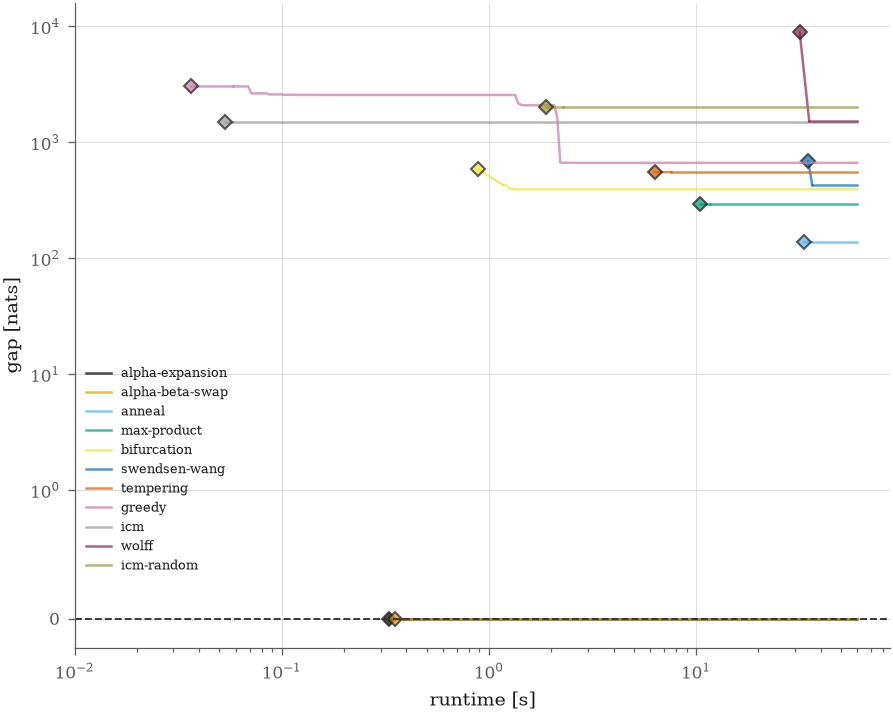

In [8]:
#: The log-spaced grid of seconds every seed is read on.
GRID = np.geomspace(1e-4, 60.0, 400)

#: Draw each solver's ±1 standard-deviation band; off by default, since with
#: every solver on the axes the bands hide the curves.
SHOW_BANDS = False

# Each solver's seeds as curves, its band on the grid, and its mean final gap:
# the legend's order, lowest first, which is also the order colours are dealt.
curves = result.curves()
final = {n: float(np.mean([c.gaps[-1] for c in cs])) for n, cs in curves.items()}
ranked = sorted(ORDER, key=final.__getitem__)
with notebook_style():
    figure = gap_panels(
        {rung.name: {n: curve_band(curves[n], GRID) for n in ranked}},
        {rung.name: final},
        start_styles(ranked),
        ylabel="gap [nats]",
        show_bands=SHOW_BANDS,
        titled=False,
        legend_above=0.1,
    )
    plt.show()

## A schedule of their own

Swendsen-Wang and Wolff above run on the single-site annealer's schedule,
exponential from `ANNEAL_START` to `ANNEAL_END`. Issue #1038 asks whether a
schedule of their own does better at the same site visits. The search is
`qa.potts_schedule`, run once outside this notebook on **tuning seeds 5 to 9**,
never on the seeds reported here. Per move and per shape (exponential, linear,
cosine), Nelder-Mead over `(log t_start, log t_end, hold)` starts at the current
schedule, is capped at 40 evaluations, and minimises the mean handed-over energy.
`hold` is the fraction of steps held at `t_end` after the ramp. The script writes
every evaluation to `docs/nb/data/potts_schedule.json`. This section reads that
file and runs only the arms it reports, on seeds 0 to 4:

- **tuned:** the schedule of lowest mean on the tuning seeds, over all three shapes.
- **warm 0.5, warm 1.0:** ICM's labelling from the cell's own generator,
  annealed on the tuned shape and hold from `t_start` 0.5 or 1.0 to the tuned
  `t_end` (`search.ground_state.warm_anneal`). The arm is charged ICM's sweeps
  plus the anneal's, within the same budget.
- **matched (Wolff only):** the current schedule at the step count at which
  Wolff's mean spend on the tuning seeds meets the budget. The script fixes the
  count by bisection before any reported run, so no run stops on its own state.

The **current** arm is the solver's row in the tables above. An arm **wins**
when its mean handover gap is below the current one by more than two standard
errors of the difference, `sqrt(sd_arm^2 + sd_current^2) / sqrt(5)`. It
**loses** when it is above by more than that. Otherwise the verdict is **no
difference**.

In [9]:
#: The tuning run, written by `python -m snakes_and_ladders.qa.potts_schedule`.
tuned = load_tuned()
#: The two cluster moves, by the names `METHODS` and the file use.
CLUSTER = {"swendsen-wang": PottsMove.SWENDSEN_WANG, "wolff": PottsMove.WOLFF}

# What the search ran on, read from the file rather than restated.
print(
    f"tuned on seeds {tuned.raw['tuning_seeds']} at {tuned.raw['budget']:,} site "
    f"visits, at most {tuned.raw['evaluations_cap']} evaluations per shape"
)
# One row per move and shape: where its search started and the best it found.
print(
    "| move | shape | warm-start gap | best gap | t_start | t_end | hold | evaluations |"
)
print("|---|---|---|---|---|---|---|---|")
for name in CLUSTER:
    for shape, trace in tuned.raw["moves"][name]["shapes"].items():
        # The first evaluation is the warm start and the best is the lowest
        # mean; both are shown as gaps above the expansion on the tuning seeds.
        best = min(trace, key=lambda entry: entry["mean"])
        print(
            f"| {name} | {shape} "
            f"| {spread([e - REFERENCE for e in trace[0]['energies']])} "
            f"| {spread([e - REFERENCE for e in best['energies']])} "
            f"| {best['t_start']:.3f} | {best['t_end']:.4f} | {best['hold']:.3f} "
            f"| {len(trace)} |"
        )
for name, params in tuned.chosen.items():
    # The schedule each move is reported on below.
    print(
        f"{name} tuned: {params.shape}, {params.t_start:.3f} to {params.t_end:.4f}, "
        f"hold {params.hold:.3f}"
    )
# The matched count and how close the tuning seeds' mean spend came to the budget.
matched = min(
    tuned.raw["matched_wolff"]["probes"],
    key=lambda probe: abs(probe["mean_spent"] - tuned.raw["budget"]),
)
print(
    f"wolff matched: {tuned.matched_steps:,} steps, mean spend "
    f"{matched['mean_spent']:,.0f} on the tuning seeds, "
    f"{len(tuned.raw['matched_wolff']['probes'])} probes"
)
host = tuned.raw["host"]
evaluations = sum(
    len(trace)
    for entry in tuned.raw["moves"].values()
    for trace in entry["shapes"].values()
)
# The search's cost, as the script recorded it on its own host.
print(
    f"search: {evaluations} evaluations of {len(tuned.raw['tuning_seeds'])} seeds and the "
    f"bisection took {host['total_seconds']:.0f} s on {host['workers']} workers, "
    f"1-minute load {host['load_before'][0]:.2f} before and {host['load_after'][0]:.2f} after"
)

tuned on seeds [5, 6, 7, 8, 9] at 34,721,000 site visits, at most 40 evaluations per shape
| move | shape | warm-start gap | best gap | t_start | t_end | hold | evaluations |
|---|---|---|---|---|---|---|---|
| swendsen-wang | exponential | 685.91 ± 15.08 | 314.55 ± 36.00 | 0.792 | 0.3615 | 0.000 | 40 |
| swendsen-wang | linear | 692.40 ± 25.19 | 299.76 ± 20.04 | 0.784 | 0.3236 | 0.000 | 40 |
| swendsen-wang | cosine | 765.05 ± 38.58 | 359.21 ± 21.41 | 0.672 | 0.0724 | 0.000 | 40 |
| wolff | exponential | 8967.37 ± 21.27 | 8827.43 ± 70.35 | 0.204 | 0.0784 | 0.000 | 40 |
| wolff | linear | 9106.27 ± 22.90 | 8851.54 ± 34.09 | 0.206 | 0.0245 | 0.043 | 40 |
| wolff | cosine | 9096.57 ± 34.36 | 8841.68 ± 60.53 | 0.191 | 0.0369 | 0.000 | 40 |
swendsen-wang tuned: linear, 0.784 to 0.3236, hold 0.000
wolff tuned: exponential, 0.204 to 0.0784, hold 0.000
wolff matched: 41,250 steps, mean spend 33,282,769 on the tuning seeds, 14 probes
search: 240 evaluations of 5 seeds and the bisection took 12

In [10]:
#: Where a warm chain's anneal starts.
WARM_STARTS = (0.5, 1.0)

# Pin BLAS to one thread in the arms' worker processes, which read the
# environment when they spawn. At the host's default threading, one energy's
# matrix-vector product took 10 ms against 5 us pinned (`qa.potts_schedule`).
for variable in THREAD_VARIABLES:
    os.environ[variable] = "1"

ARMS = {}
for name, move in CLUSTER.items():
    params = tuned.chosen[name]
    # The tuned schedule, cold from a uniform draw, at the budget's step count.
    ARMS[f"{name} tuned"] = functools.partial(
        ScheduleStart, move, SOLVER_BUDGET, params, None, False
    )
    for t_start in WARM_STARTS:
        # ICM's labelling annealed from `t_start` on the tuned shape, hold and end.
        ARMS[f"{name} warm {t_start}"] = functools.partial(
            ScheduleStart,
            move,
            SOLVER_BUDGET,
            replace(params, t_start=t_start),
            None,
            True,
        )
# Wolff on the current schedule at the step count fixed on the tuning seeds.
ARMS["wolff matched"] = functools.partial(
    ScheduleStart,
    PottsMove.WOLFF,
    SOLVER_BUDGET,
    ANNEAL_SCHEDULE,
    tuned.matched_steps,
    False,
)

arms_load_before = os.getloadavg()
arms_opened = time.perf_counter()
# Every arm through the same seam, polish and seeds as the solvers above.
arm_result = StartsBenchmark(
    PottsObjective(rung),
    ARMS,
    polish_by_icm,
    seeding_budget=Budget(Cost.EVALUATIONS, 1),
    polish_budget=POLISH,
    seeds=SEEDS,
    workers=WORKERS,
    reference=[REFERENCE],
).run()
arms_elapsed = time.perf_counter() - arms_opened
arms_load_after = os.getloadavg()
# The cell count, the one line here continuous in the seeds.
print(f"{len(ARMS) * len(SEEDS)} cells of {len(ARMS)} arms at {len(SEEDS)} seeds")

35 cells of 7 arms at 5 seeds


In [11]:
#: The two-standard-error test of an arm against the current schedule.
def verdict(arm: list[float], current: list[float]) -> str:
    # The difference of mean gaps against two standard errors of it.
    difference = float(np.mean(current) - np.mean(arm))
    error = float(
        np.sqrt(np.var(arm, ddof=1) + np.var(current, ddof=1)) / np.sqrt(len(arm))
    )
    if difference > 2 * error:
        word = "win"
    elif difference < -2 * error:
        word = "loss"
    else:
        word = "no difference"
    return f"{word} ({difference:+.2f} against 2 SE {2 * error:.2f})"


# One row per move and arm, the current arm first as the reference.
print("| move | arm | handed over gap | gap after ICM | site visits | verdict |")
print("|---|---|---|---|---|---|")
for name in CLUSTER:
    # The current arm is the solver's own cells from the first run.
    rows = {"current": result.trials(name)}
    rows.update(
        {
            arm.removeprefix(f"{name} "): arm_result.trials(arm)
            for arm in ARMS
            if arm.startswith(name)
        }
    )
    current = [t.seeded_value - REFERENCE for t in rows["current"]]
    for arm, trials in rows.items():
        handed = [t.seeded_value - REFERENCE for t in trials]
        print(
            f"| {name} | {arm} | {spread(handed)} "
            f"| {spread([t.value - REFERENCE for t in trials])} "
            f"| {spread([t.diagnostics['site_visits'] for t in trials], 0)} "
            f"| {'reference' if arm == 'current' else verdict(handed, current)} |"
        )

| move | arm | handed over gap | gap after ICM | site visits | verdict |
|---|---|---|---|---|---|
| swendsen-wang | current | 688.23 ± 40.76 | 430.07 ± 16.45 | 34721000 ± 0 | reference |
| swendsen-wang | tuned | 299.62 ± 33.26 | 203.04 ± 29.59 | 34721000 ± 0 | win (+388.61 against 2 SE 47.05) |
| swendsen-wang | warm 0.5 | 511.39 ± 47.25 | 402.93 ± 41.41 | 34721000 ± 0 | win (+176.84 against 2 SE 55.81) |
| swendsen-wang | warm 1.0 | 417.03 ± 32.90 | 266.52 ± 18.43 | 34721000 ± 0 | win (+271.20 against 2 SE 46.85) |
| wolff | current | 8977.23 ± 45.13 | 1532.63 ± 59.33 | 10850 ± 229 | reference |
| wolff | tuned | 8864.21 ± 26.42 | 1585.16 ± 89.57 | 12772 ± 457 | win (+113.02 against 2 SE 46.78) |
| wolff | warm 0.5 | 1093.04 ± 74.75 | 888.34 ± 94.83 | 2794216 ± 999386 | win (+7884.19 against 2 SE 78.10) |
| wolff | warm 1.0 | 1259.13 ± 53.91 | 900.70 ± 102.64 | 2528682 ± 760922 | win (+7718.10 against 2 SE 62.89) |
| wolff | matched | 3060.08 ± 58.05 | 617.02 ± 23.80 | 34804303 ± 58

In [12]:
# The arms' wall clock and the load it was read under.
longest_arm = max(t.seconds[-1] for arm in ARMS for t in arm_result.trials(arm))
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{arms_load_before[0]:.2f} before and {arms_load_after[0]:.2f} after; "
    f"{len(ARMS) * len(SEEDS)} cells took {arms_elapsed:.0f} s, the longest "
    f"{longest_arm:.2f} s against the {CEILING.size} s ceiling"
)
# The arms are held to the same per-cell ceiling as the solvers.
assert longest_arm <= CEILING.size

host: 4 cores, 4 workers; 1-minute load 13.52 before and 7.27 after; 35 cells took 76 s, the longest 40.57 s against the 120 s ceiling


### The schedules, and the search that chose them

The left panels plot each arm's temperature against the fraction of its anneal's steps. That axis puts
arms of different step counts on one scale: the matched Wolff arm is the current
curve over its own step count, and a warm chain's anneal runs the budget left after ICM.
The right panels plot every evaluation of the search as its mean gap on the tuning seeds, one
colour per shape, with the running best per shape and the warm start as the
dashed line.

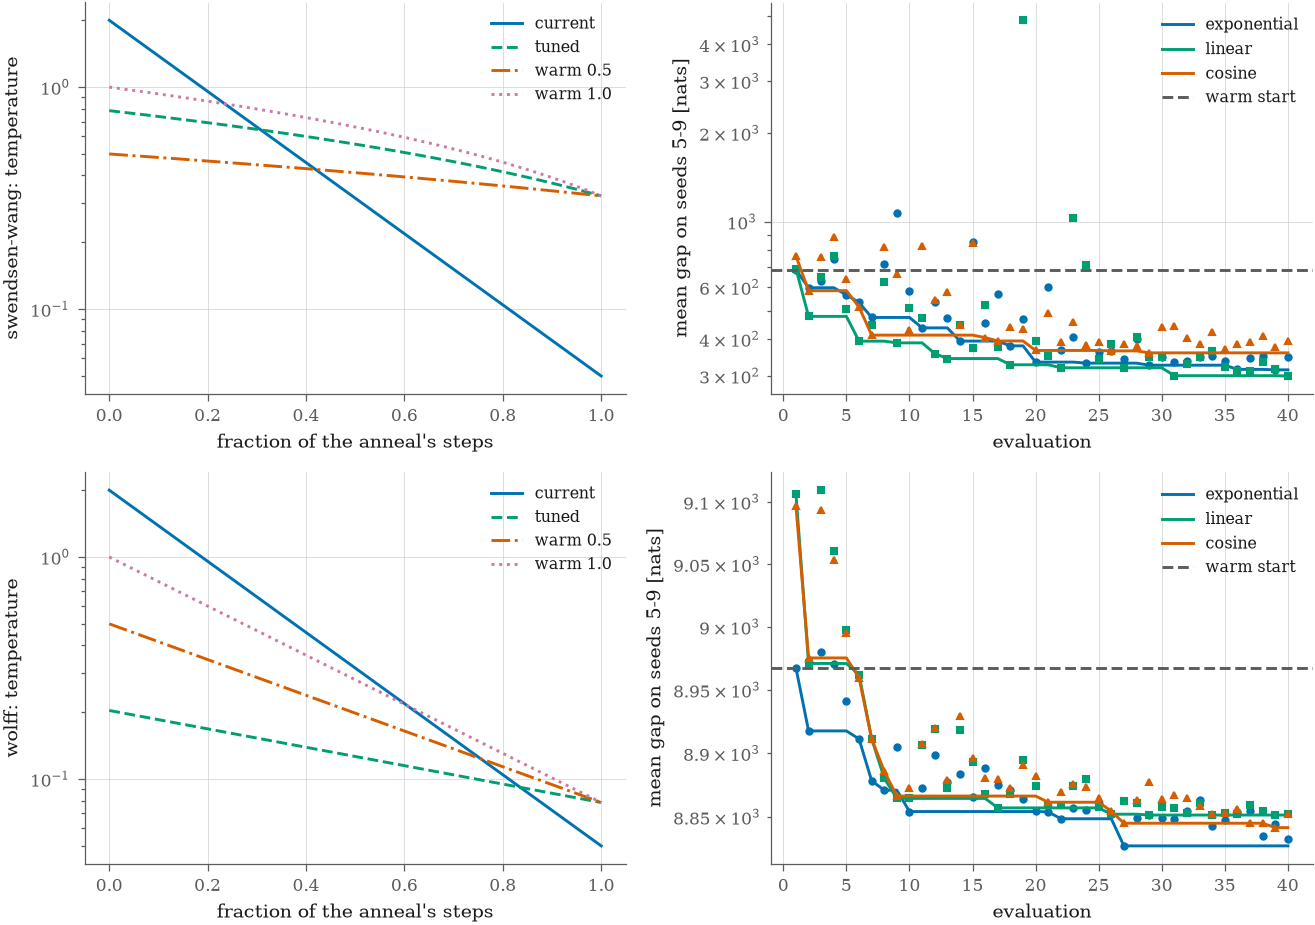

In [13]:
#: Steps drawn per curve: the budget's count, enough to show the shape.
DRAWN = SWEEPS
with notebook_style():
    # One row per move: its schedules on the left, its search on the right.
    figure, axes = plt.subplots(2, 2, figsize=(9.0, 6.4))
    for row, name in zip(axes, CLUSTER, strict=True):
        params = tuned.chosen[name]
        curves = {"current": ANNEAL_SCHEDULE, "tuned": params} | {
            f"warm {t}": replace(params, t_start=t) for t in WARM_STARTS
        }
        fraction = np.arange(DRAWN) / (DRAWN - 1)
        for index, (label, schedule) in enumerate(curves.items()):
            # Each schedule built at the drawn length, read step by step.
            style = series_style(index)
            row[0].plot(
                fraction,
                temperatures(schedule.build(DRAWN)),
                color=style["color"],
                linestyle=style["linestyle"],
                label=label,
            )
        # Temperature on a log axis, where an exponential ramp is straight.
        row[0].set_yscale("log")
        row[0].set_xlabel("fraction of the anneal's steps")
        row[0].set_ylabel(f"{name}: temperature")
        row[0].legend(fontsize="small")
        for index, (shape, trace) in enumerate(
            tuned.raw["moves"][name]["shapes"].items()
        ):
            # Every evaluation's mean gap, and the best so far, per shape.
            style = series_style(index)
            gaps = np.array([entry["mean"] for entry in trace]) - REFERENCE
            order = np.arange(1, len(gaps) + 1)
            row[1].plot(
                order,
                gaps,
                color=style["color"],
                marker=style["marker"],
                linestyle="none",
                markersize=3,
            )
            row[1].plot(
                order, np.minimum.accumulate(gaps), color=style["color"], label=shape
            )
        # The warm start, the current schedule on the tuning seeds, for scale.
        row[1].axhline(
            tuned.raw["moves"][name]["shapes"]["exponential"][0]["mean"] - REFERENCE,
            color=INK_MUTED,
            linestyle="--",
            label="warm start",
        )
        # Gap on a log axis, so the descent below the warm start stays legible.
        row[1].set_yscale("log")
        row[1].set_xlabel("evaluation")
        row[1].set_ylabel("mean gap on seeds 5-9 [nats]")
        row[1].legend(fontsize="small")
    # Draw the grid without overlapping labels.
    figure.tight_layout()
    plt.show()

## Cluster moves against the graph cuts

The graph cuts hand over their own labelling on every seed, and Swendsen-Wang
on its tuned schedule ends 299.6 above it. Issue #1041's hypothesis is that a
Fortuin-Kasteleyn bond reads the coupling and not the field. A cluster then
spans sites whose fields prefer different labels, and one recolouring cannot
suit all of them. The heavy runs are `qa.potts_clusters`, run once outside
this notebook into `docs/nb/data/potts_clusters.json`. This section reads that
file, and reruns two arms at one seed to check the file against the code.

**The diagnosis** runs on tuning seeds 5 to 9: Swendsen-Wang on its tuned
schedule, and Wolff at its matched step count on the current one, each on the
Python pass so every cluster's members are read. Per schedule step it records
the mean and largest cluster, the accept rate, and the sites relabelled. It
also records the fraction of relabelled sites **not of their cluster's
majority preference** (*mixed*), where a site's preference is the label its
own field puts highest. The same fraction is recorded over every cluster of
two or more sites, accepted or not. The ghost-spin arm is dropped if fewer
than 5% of Swendsen-Wang's relabelled sites are mixed. That rule is fixed in
the script before the run.

**The arms** run on seeds 0 to 4. They share the budget, the polish and the
generator per cell of the tables above, and each is charged every part's site
visits:

- **niedermayer matched:** Niedermayer's rule at its threshold, which on a
  ferromagnet builds Wolff's bonds and transposes two labels on the cluster.
  It runs on Swendsen-Wang's tuned schedule, at a step count matched to the
  budget on the tuning seeds. Its own schedule is not tuned: one run took
  30.3 s on the reported seeds, against Swendsen-Wang's 0.9 s.
- **swendsen-wang>expansion:** Swendsen-Wang tuned, less ten expansion cycles
  of budget, and then alpha-expansion from its labelling.
- **expansion>swendsen-wang:** alpha-expansion, and then Swendsen-Wang from its
  labelling on the rest of the budget. The schedule runs linear from the tuned
  end, 0.324, to 0.05.
- **ghost-spin:** Swendsen-Wang with the field as bonds to one ghost site per
  label (`sample.potts_mcmc.ghost_spin_sweep`). It has no accept step, and each
  step is charged one ghost bond per site more.
- **label-directed:** Swendsen-Wang's clusters, each proposed onto one label,
  with the label cycling by step, and a Metropolis-Hastings step on the
  cluster's field change (`sample.potts_mcmc.label_directed_sweep`).
- **tempering + houdayer:** six Swendsen-Wang replicas geometric from 0.324
  to 0.784, the tuned endpoints. A Houdayer move runs between the two coldest
  replicas, with an accept step across the two temperatures, and exchanges
  run between neighbours (`sample.potts_mcmc.cluster_tempering`).

Both new kernels and the tempering are held to the enumerated Gibbs law of a
3x3 lattice at three labels before any release run, and an ablation of each
new kernel is refuted by the same bound
(`tests/regression/sample/test_potts_cluster_field.py`). An arm **wins**
against tuned Swendsen-Wang when its mean handover gap is below it by more than
two standard errors, `sqrt(sd_arm^2 + sd_tuned^2) / sqrt(5)`.

**No labelling here can end below the expansion.** The field is
`alpha[m] c_i`, linear in the class value. Moving every site of an inner class
to whichever ladder end their summed `c_i` favours does not raise the field
term. It keeps the agreements inside the class and cannot remove one to
outside it. So the ten-class optimum is the two-class one, which the graph
cut solves exactly (`search.ground_state.ends_labelling`). The enumeration of
`spatio_only/ci`'s 19,683 labellings confirms it
(`tests/regression/search/test_cluster_moves.py`).

In [14]:
#: The diagnosis and the arms, written by `python -m snakes_and_ladders.qa.potts_clusters`.
clusters = load_clusters()
DIAGNOSED = clusters["diagnosis"]["moves"]

# What each diagnosed run was, and what it cost on the script's host.
print(
    f"diagnosis on seeds {clusters['diagnosis']['tuning_seeds']}: "
    + "; ".join(
        f"{name} {entry['steps']:,} steps, {np.mean(entry['seconds']):.0f} s a run"
        for name, entry in DIAGNOSED.items()
    )
)
# One row per move: the whole run's cluster and field statistics, summed over seeds.
print(
    "| move | mean cluster | largest | accept rate | relabelled per seed "
    "| drawn label not preferred | relabelled, mixed | clusters >= 2, mixed |"
)
print("|---|---|---|---|---|---|---|---|")
for name, entry in DIAGNOSED.items():
    whole = entry["whole_run"]
    print(
        f"| {name} | {whole['mean_cluster']:.2f} | {whole['max_cluster']:,.0f} "
        f"| {whole['accept_rate']:.3f} | {whole['relabelled_per_seed']:,.0f} "
        f"| {whole['disagree_fraction']:.3f} | {whole['mixed_fraction']:.3f} "
        f"| {whole['multi_mixed_fraction']:.3f} |"
    )
# The rule fixed before the run, applied to Swendsen-Wang's mixed fraction.
mixed = DIAGNOSED["swendsen-wang"]["whole_run"]["mixed_fraction"]
floor = clusters["mixed_floor"]
print(
    f"ghost-spin arm: {'kept' if mixed >= floor else 'dropped'} "
    f"(mixed {mixed:.3f} against the floor {floor})"
)
# Niedermayer's matched count, and how close its mean spend came to the budget.
matched_n = clusters["matched_niedermayer"]
nearest = min(
    matched_n["probes"], key=lambda probe: abs(probe["mean_spent"] - clusters["budget"])
)
print(
    f"niedermayer matched: {matched_n['steps']:,} steps, mean spend "
    f"{nearest['mean_spent']:,.0f} of {clusters['budget']:,} on the tuning seeds, "
    f"{len(matched_n['probes'])} probes"
)

diagnosis on seeds [5, 6, 7, 8, 9]: swendsen-wang 1,000 steps, 28 s a run; wolff 41,250 steps, 22 s a run
| move | mean cluster | largest | accept rate | relabelled per seed | drawn label not preferred | relabelled, mixed | clusters >= 2, mixed |
|---|---|---|---|---|---|---|---|
| swendsen-wang | 7.97 | 2,691 | 0.681 | 560,893 | 0.875 | 0.133 | 0.373 |
| wolff | 134.48 | 1,232 | 0.391 | 32,501 | 0.840 | 0.240 | 0.335 |
ghost-spin arm: kept (mixed 0.133 against the floor 0.05)
niedermayer matched: 46,083 steps, mean spend 31,949,890 of 34,721,000 on the tuning seeds, 8 probes


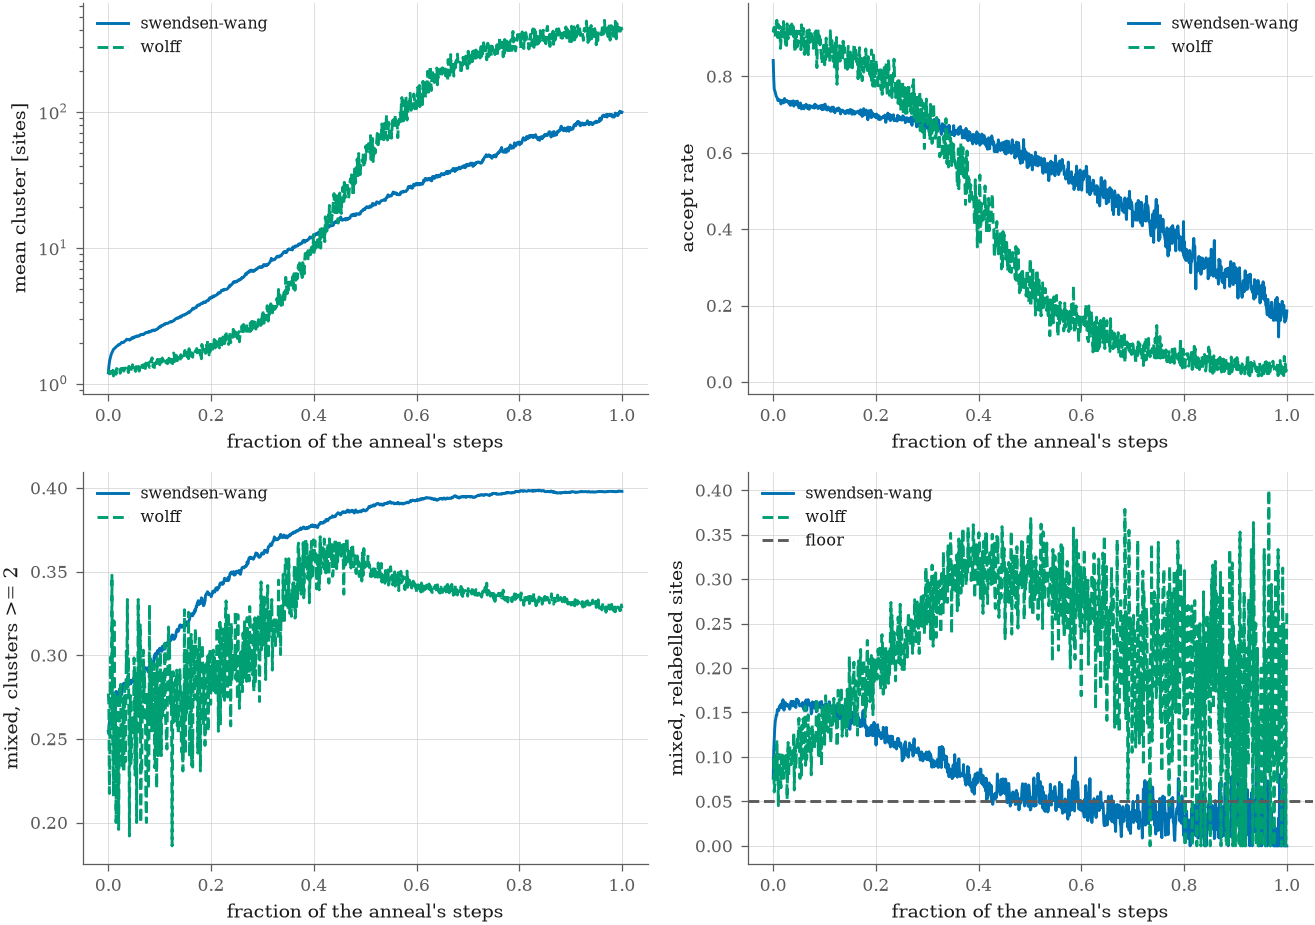

In [15]:
#: What each panel plots from a diagnosis row, and its axis label.
PANELS = {
    "mean_cluster": "mean cluster [sites]",
    "accept_rate": "accept rate",
    "multi_mixed_fraction": "mixed, clusters >= 2",
    "mixed_fraction": "mixed, relabelled sites",
}
with notebook_style():
    # One panel per statistic, both moves on each against the anneal's progress.
    figure, axes = plt.subplots(2, 2, figsize=(9.0, 6.4))
    for axis, (key, label) in zip(axes.flat, PANELS.items(), strict=True):
        for index, (name, entry) in enumerate(DIAGNOSED.items()):
            # Each row is a bin of the schedule's steps, read as a fraction.
            values = np.array(entry["per_row"][key], dtype=float)
            fraction = np.arange(values.size) / (values.size - 1)
            style = series_style(index)
            axis.plot(
                fraction,
                values,
                color=style["color"],
                linestyle=style["linestyle"],
                label=name,
            )
        axis.set_xlabel("fraction of the anneal's steps")
        axis.set_ylabel(label)
        axis.legend(fontsize="small")
    # Cluster size on a log axis: it spans three decades over the anneal.
    axes[0, 0].set_yscale("log")
    # The floor the ghost-spin rule reads, on the relabelled-mixed panel.
    axes[1, 1].axhline(floor, color=INK_MUTED, linestyle="--", label="floor")
    axes[1, 1].legend(fontsize="small")
    figure.tight_layout()
    plt.show()

In [16]:
#: The arm every other is judged against, and the file's reference energy.
TUNED = "swendsen-wang tuned"
ARM_ROWS = clusters["arms"]["arms"]
FILE_REFERENCE = clusters["arms"]["reference"]

# The file's reference is this notebook's, and its tuned arm is the #1038 arm above.
assert FILE_REFERENCE == REFERENCE
assert ARM_ROWS[TUNED]["handed"] == [
    t.seeded_value for t in arm_result.trials("swendsen-wang tuned")
]
tuned_gaps = [value - REFERENCE for value in ARM_ROWS[TUNED]["handed"]]
# One row per arm: gaps before and after ICM, spend, seconds, and the verdict.
print("| arm | handed over gap | gap after ICM | site visits | seconds | verdict |")
print("|---|---|---|---|---|---|")
for arm, row in ARM_ROWS.items():
    handed = [value - REFERENCE for value in row["handed"]]
    print(
        f"| {arm} | {spread(handed)} "
        f"| {spread([value - REFERENCE for value in row['polished']])} "
        f"| {spread(row['visits'], 0)} | {spread(row['seconds'], 1)} "
        f"| {'reference' if arm == TUNED else verdict(handed, tuned_gaps)} |"
    )
# Houdayer's cluster in the tempering arm, which percolates or does not.
houdayer = ARM_ROWS["tempering + houdayer"]
print(
    f"tempering + houdayer: Houdayer cluster {spread(houdayer['cluster_mean'], 1)} "
    f"sites of {rung.n_nodes:,}, accepted {spread(houdayer['cluster_accept'], 3)}"
)
# Every labelling that ended below the expansion, recomputed by `sim.potts.energy`.
below = {
    arm: row["below_reference"]
    for arm, row in ARM_ROWS.items()
    if row["below_reference"]
}
print(f"labellings below the expansion: {below if below else 'none'}")
host = clusters["host"]
# The script's cost on its own host, per part.
for part in ("diagnosis", "matched", "arms"):
    print(
        f"{part}: {host[part]['seconds']:.0f} s on {host[part]['workers']} workers, "
        f"1-minute load {host[part]['load_before'][0]:.2f} before and "
        f"{host[part]['load_after'][0]:.2f} after"
    )

| arm | handed over gap | gap after ICM | site visits | seconds | verdict |
|---|---|---|---|---|---|
| swendsen-wang tuned | 299.62 ± 33.26 | 203.04 ± 29.59 | 34721000 ± 0 | 0.9 ± 0.2 | reference |
| niedermayer matched | 2678.18 ± 41.97 | 546.31 ± 20.81 | 30884101 ± 6035312 | 30.3 ± 3.7 | loss (-2378.56 against 2 SE 47.90) |
| swendsen-wang>expansion | 0.00 ± 0.00 | 0.00 ± 0.00 | 32290530 ± 0 | 0.7 ± 0.0 | win (+299.62 against 2 SE 29.75) |
| expansion>swendsen-wang | 0.00 ± 0.00 | 0.00 ± 0.00 | 34721000 ± 0 | 0.6 ± 0.0 | win (+299.62 against 2 SE 29.75) |
| ghost-spin | 1447.69 ± 79.30 | 961.45 ± 82.52 | 34712226 ± 0 | 0.8 ± 0.0 | loss (-1148.07 against 2 SE 76.92) |
| label-directed | 532.49 ± 30.85 | 355.38 ± 19.18 | 34721000 ± 0 | 0.9 ± 0.0 | loss (-232.87 against 2 SE 40.57) |
| tempering + houdayer | 997.46 ± 59.71 | 483.55 ± 49.46 | 34512674 ± 0 | 1.8 ± 0.1 | loss (-697.84 against 2 SE 61.13) |
tempering + houdayer: Houdayer cluster 579.9 ± 40.9 sites of 5,041, accepted 0.363 

In [17]:
#: The arms rerun here, at one seed, against the file.
RERUN = ("ghost-spin", "label-directed")

# The two new kernels' arms, at seed 0, through the seam the script ran them in:
# two worker processes, whose BLAS the pin above holds to one thread, as the
# script's are. One worker would run in this process, unpinned.
check = StartsBenchmark(
    PottsObjective(rung),
    {name: cluster_arms()[name] for name in RERUN},
    polish_by_icm,
    seeding_budget=Budget(Cost.EVALUATIONS, 1),
    polish_budget=POLISH,
    seeds=[0],
    workers=2,
    reference=[REFERENCE],
).run()
for name in RERUN:
    # The handover and the polish, bitwise the file's seed 0.
    trial = check.trials(name)[0]
    assert trial.seeded_value == ARM_ROWS[name]["handed"][0]
    assert trial.value == ARM_ROWS[name]["polished"][0]
    print(
        f"{name} seed 0: handed over {trial.seeded_value - REFERENCE:.2f}, "
        "equal to the file's"
    )

# The two-end reduction on the ghost-spin arm's polished labelling at seed 0.
labelling = check.trials("ghost-spin")[0].theta.numpy()
reduced = ends_labelling(rung, labelling)
print(
    f"ghost-spin seed 0: {len(np.unique(labelling))} classes at gap "
    f"{energy(rung.graph, rung.field, labelling) - REFERENCE:.2f}; on the two ends "
    f"{len(np.unique(reduced))} classes at gap "
    f"{energy(rung.graph, rung.field, reduced) - REFERENCE:.2f}"
)

ghost-spin seed 0: handed over 1330.05, equal to the file's
label-directed seed 0: handed over 501.50, equal to the file's
ghost-spin seed 0: 9 classes at gap 831.57; on the two ends 2 classes at gap 435.74


## A tiling field

Every section above runs on `spatio_only/release`, whose field is linear in
the state, so its ten-state optimum is the two-state graph cut. Issue #1050
asks for an instance where that reduction fails. `spatio_tiling/release` keeps
the lattice, the ten states and the coupling, and replaces the field. A seeded
Voronoi tiling, `sim.potts.tile_partition`, splits the 5,041 sites into 16
connected tiles. Tile `t` rewards one state `a_t` by `s_t` and no other
(`sim.potts.tiling_field`). The strengths are log-spaced from 0.1 J to 10 J,
and the ten states are planted in order and then the first six again.

No optimum is known here. Alpha-expansion's factor-2 bracket still holds, and
the planted states give a second referee. Let `b_t` be the most coupling any
one site of tile `t` has to sites outside it. A tile with `s_t > b_t` carries
its state at every site in every labelling no expansion or swap move lowers,
the optimum included (`search.potts_starts.recovery_bound`). Below the bound
the recovery is measured.

In [18]:
# The declared instance: tests/regression/fixtures/spatio_tiling/release.yaml.
tiling = tiling_rung(fixture("spatio_tiling", "release").params, "release-tiling")
# The same lattice as the rung above, so one sweep costs the same site visits
# and `SOLVER_BUDGET` and the tuned arms' budgets carry over unchanged.
assert tiling.visits_per_sweep == rung.visits_per_sweep
# The expansion's energy on this field, and the bracket its factor-2 bound gives.
TILING_REFERENCE = run_alpha_expansion(
    tiling, SOLVER_BUDGET, np.random.default_rng(0)
).energy
tiling_bracket = expansion_bracket(tiling, TILING_REFERENCE)
# The planted labelling, every site in its tile's state, scored by `sim.potts.energy`.
planted = tiling.states[tiling.tiles]
PLANTED_GAP = energy(tiling.graph, tiling.field, planted) - TILING_REFERENCE
# The recovery bound per tile, and the tiles whose strength clears it.
bound = recovery_bound(tiling)
held = tiling.strengths > bound
print(
    f"{tiling.n_nodes} sites, {len(np.unique(tiling.tiles))} tiles of "
    f"{np.bincount(tiling.tiles).min()} to {np.bincount(tiling.tiles).max()} sites, "
    f"q = {tiling.n_states}"
)
print(
    f"expansion {TILING_REFERENCE:.2f}, bracket [{tiling_bracket.lower:.2f}, "
    f"{tiling_bracket.upper:.2f}], planted labelling {PLANTED_GAP:.2f} above it"
)
print(f"tiles clearing their bound: {np.flatnonzero(held).tolist()}")

5041 sites, 16 tiles of 145 to 665 sites, q = 10
expansion -17021.99, bracket [-17315.32, -17021.99], planted labelling 12.53 above it
tiles clearing their bound: [12, 13, 14, 15]


### Every solver, and the two tuned arms

Every `METHODS` solver runs at `SOLVER_BUDGET` through the same seam, polish and
seeds as the first run. Four solvers read no generator: greedy, the two graph
cuts and max-product. Each returns one labelling at every seed, so each runs at
seed 0 alone. Max-product floods up to 1,000 iterations on this field, and one
of its cells took 145 s on a scratch run at a 1-minute load of 5; five
identical cells would cost the notebook ten minutes. The tuned Swendsen-Wang
arm and the matched Wolff arm of issue #1038 run as they are defined above.

In [19]:
#: The solvers that read no generator, run at seed 0 alone.
DETERMINISTIC = ("greedy", "alpha-expansion", "alpha-beta-swap", "max-product")
#: The #1038 arms, reused from `ARMS` as they are.
TUNED_ARMS = ("swendsen-wang tuned", "wolff matched")
#: Rows of the tiling tables, in `METHODS` order and then the two arms.
TILING_ORDER = ORDER + list(TUNED_ARMS)

# The stochastic solvers and the two arms, built per cell from each generator.
stochastic = {
    name: functools.partial(SolverStart, name, SOLVER_BUDGET)
    for name in ORDER
    if name not in DETERMINISTIC
} | {name: ARMS[name] for name in TUNED_ARMS}
# The deterministic solvers, one cell each.
fixed = {
    name: functools.partial(SolverStart, name, SOLVER_BUDGET) for name in DETERMINISTIC
}

tiling_load_before = os.getloadavg()
tiling_opened = time.perf_counter()
tiling_results = {}
for group, seeds in ((stochastic, SEEDS), (fixed, [0])):
    # Each group through the seam on four workers, against the expansion's energy.
    tiling_results[len(seeds)] = StartsBenchmark(
        PottsObjective(tiling),
        group,
        polish_by_icm,
        seeding_budget=Budget(Cost.EVALUATIONS, 1),
        polish_budget=POLISH,
        seeds=seeds,
        workers=WORKERS,
        reference=[TILING_REFERENCE],
    ).run()
tiling_elapsed = time.perf_counter() - tiling_opened
tiling_load_after = os.getloadavg()


def tiling_trials(name: str) -> list:
    # One solver's trials, from whichever group ran it.
    return tiling_results[1 if name in DETERMINISTIC else len(SEEDS)].trials(name)


# The cell count, the one line here continuous in the seeds.
tiling_cells = sum(len(tiling_trials(name)) for name in TILING_ORDER)
print(f"{tiling_cells} cells of {len(TILING_ORDER)} solvers and arms")

49 cells of 13 solvers and arms


In [20]:
#: The wall clock a tiling cell may take: max-product's one cell sets it.
TILING_CEILING = Budget(Cost.SECONDS, 300)
# Every cell's seconds, and the load they were read under.
tiling_longest = {
    name: max(t.seconds[-1] for t in tiling_trials(name)) for name in TILING_ORDER
}
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{tiling_load_before[0]:.2f} before and {tiling_load_after[0]:.2f} after; "
    f"{tiling_cells} cells took {tiling_elapsed:.0f} s; longest cells "
    + ", ".join(
        f"{name} {seconds:.1f} s"
        for name, seconds in sorted(tiling_longest.items(), key=lambda kv: -kv[1])[:3]
    )
)
assert max(tiling_longest.values()) <= TILING_CEILING.size

host: 4 cores, 4 workers; 1-minute load 7.01 before and 4.52 after; 49 cells took 140 s; longest cells wolff matched 58.8 s, max-product 39.9 s, anneal 2.1 s


### Gaps against the expansion, and what each solver recovers

Per solver: the gap its handover and its polished labelling sit above the
expansion, mean ± sample standard deviation over the seeds (one seed, and no
spread, for the four deterministic solvers); the tiles whose polished
labelling carries the tile's state at every site, of 16; whether every tile
clearing its bound is among them; and the mean fraction of each tile's sites
carrying its state. A negative gap is a labelling below the expansion and
inside the bracket.

In [21]:
def tiling_spread(values: list[float], digits: int = 2) -> str:
    # The mean, with the sample standard deviation where there is more than one seed.
    if len(values) == 1:
        return f"{values[0]:.{digits}f}"
    return spread(values, digits)


# The expansion's own recovery, the row every other is read beside.
print(f"{tiling.name}: reference {TILING_REFERENCE:.2f}, planted {PLANTED_GAP:+.2f}")
print(
    "| solver | seeds | handed over gap | final gap | full tiles | bounded held | mean recovery |"
)
print("|---|---|---|---|---|---|---|")
for name in TILING_ORDER:
    trials = tiling_trials(name)
    # Each seed's polished labelling read against the planted states, per tile.
    recovered = np.array([recovery(tiling, t.theta.numpy()) for t in trials])
    print(
        f"| {name} | {len(trials)} "
        f"| {tiling_spread([t.seeded_value - TILING_REFERENCE for t in trials])} "
        f"| {tiling_spread([t.value - TILING_REFERENCE for t in trials])} "
        f"| {tiling_spread((recovered == 1.0).sum(axis=1).tolist(), 1)} "
        f"| {bool((recovered[:, held] == 1.0).all())} "
        f"| {recovered.mean():.3f} |"
    )
# Every labelling below the expansion, rescored by `sim.potts.energy`.
below = {
    name: [
        round(energy(tiling.graph, tiling.field, t.theta.numpy()) - TILING_REFERENCE, 2)
        for t in tiling_trials(name)
        if t.value < TILING_REFERENCE
    ]
    for name in TILING_ORDER
}
print(f"below the expansion after ICM: { {k: v for k, v in below.items() if v} }")
# The bracket's width, which no labelling above can narrow from below.
print(
    f"bracket width {tiling_bracket.upper - tiling_bracket.lower:.2f}; the lowest "
    f"final energy is {min(t.value for n in TILING_ORDER for t in tiling_trials(n)) - TILING_REFERENCE:+.2f}"
)

release-tiling: reference -17021.99, planted +12.53
| solver | seeds | handed over gap | final gap | full tiles | bounded held | mean recovery |
|---|---|---|---|---|---|---|
| greedy | 1 | 12.53 | 8.03 | 12.0 | True | 0.999 |
| icm | 5 | 339.00 ± 73.74 | 339.00 ± 73.74 | 8.2 ± 0.4 | True | 0.756 |
| icm-random | 5 | 64.65 ± 30.10 | 64.65 ± 30.10 | 8.8 ± 1.3 | True | 0.961 |
| anneal | 5 | -0.04 ± 0.08 | -0.10 ± 0.08 | 10.0 ± 0.0 | True | 0.987 |
| swendsen-wang | 5 | 126.17 ± 17.71 | 10.29 ± 3.90 | 8.8 ± 0.8 | True | 0.978 |
| wolff | 5 | 14593.34 ± 54.92 | 287.45 ± 65.98 | 8.6 ± 0.5 | True | 0.817 |
| tempering | 5 | 20.77 ± 11.99 | 20.38 ± 11.70 | 9.6 ± 1.1 | True | 0.948 |
| alpha-expansion | 1 | 0.00 | 0.00 | 10.0 | True | 0.987 |
| alpha-beta-swap | 1 | 0.02 | 0.02 | 10.0 | True | 0.986 |
| max-product | 1 | 12.53 | 8.03 | 12.0 | True | 0.999 |
| bifurcation | 5 | 6204.02 ± 137.24 | 728.22 ± 33.42 | 7.0 ± 0.0 | True | 0.534 |
| swendsen-wang tuned | 5 | 58.95 ± 6.56 | 4.80 ± 4.59

### Recovery against strength

Each tile's recovery at seed 0, after ICM, for alpha-expansion, annealing, tuned
Swendsen-Wang and ICM, one per colour of the palette. On the left against the tile's
strength in units of the coupling, on the right against its strength over its
own bound `b_t`. Right of the dashed line the bound says every graph-cut local
minimum recovers the tile in full; left of it the recovery is a measurement.

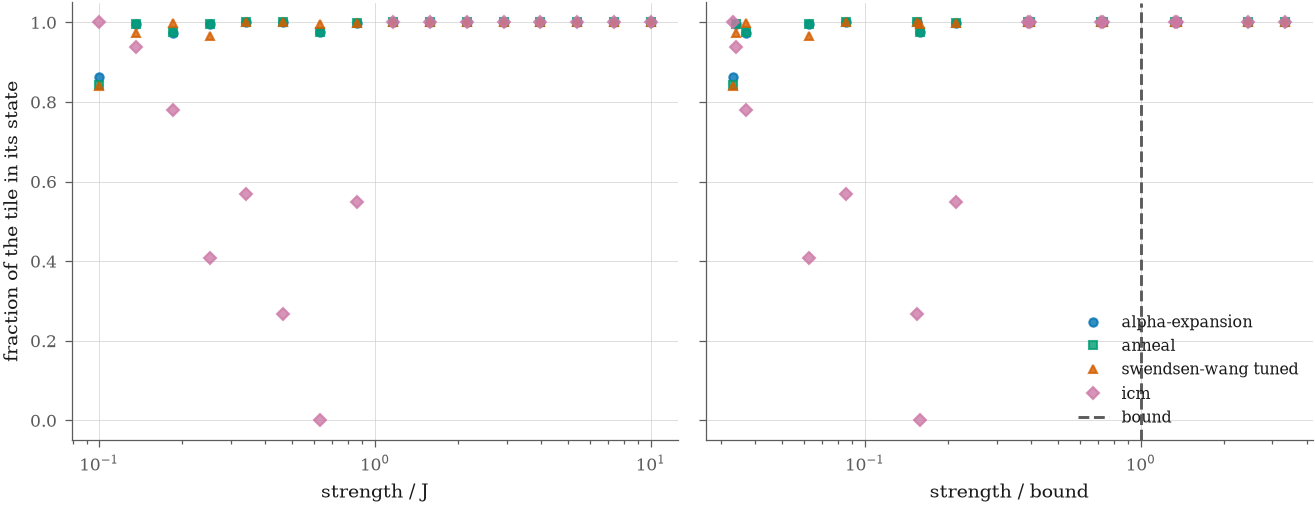

In [22]:
#: The solvers the panel draws, one per palette colour: a graph cut, the two
#: annealers and single-site descent.
DRAWN_SOLVERS = ("alpha-expansion", "anneal", "swendsen-wang tuned", "icm")
# Strength in units of the coupling, and over each tile's own bound.
coupling = float(np.asarray(tiling.graph.edge_coupling)[0])
axes_x = {
    "strength / J": tiling.strengths / coupling,
    "strength / bound": tiling.strengths / bound,
}
with notebook_style():
    # Two panels sharing the recovery axis.
    figure, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), sharey=True)
    for axis, (label, x) in zip(axes, axes_x.items(), strict=True):
        for index, name in enumerate(DRAWN_SOLVERS):
            # Seed 0's polished labelling, read per tile against the planted states.
            fractions = recovery(tiling, tiling_trials(name)[0].theta.numpy())
            style = series_style(index)
            axis.plot(
                x,
                fractions,
                color=style["color"],
                marker=style["marker"],
                linestyle="none",
                alpha=0.8,
                label=name,
            )
        axis.set_xscale("log")
        axis.set_xlabel(label)
    # The bound at a ratio of one, on the right panel.
    axes[1].axvline(1.0, color=INK_MUTED, linestyle="--", label="bound")
    axes[0].set_ylabel("fraction of the tile in its state")
    axes[1].legend(fontsize="small")
    figure.tight_layout()
    plt.show()

## Read

**The graph cuts reach the exact two-state ground state, and nothing reaches
below it.** Alpha-expansion and alpha-beta swap hand over -10,454.16 on every
seed. That is the graph-cut ground state of the same fixture at `q = 2`
(`RELEASE_Q2_ENERGY`, -10,454.156 in `test_ground_state.py`). Their labelling
uses only the ladder's two ends, 3,286 and 1,755 sites, with a tilt of 0.215
against that ground state's 0.2151. The ten-state optimum is at most this
energy and at least the bracket's -11,521.58. The section on cluster moves
closes that bracket: the field is linear in the class value, so the eight
inner classes cannot lower the energy, and -10,454.16 is the ten-state
optimum (`search.ground_state.ends_labelling`, issue #1041).

**Nothing else reaches it, before or after the polish.** Annealing ends
138.0 ± 32.8 above it and max-product 293.7. Bifurcation and Swendsen-Wang end
393.7 and 430.1, tempering 553.6, and greedy 666.1 after ICM takes it down from
3,036.1. Wolff, ICM and ICM in a random order end 1,510 to 2,000 above.

**Wolff underspends its budget, and this is where it shows.** Its annealed
run takes one cluster per step, for as many steps as a heat-bath sweep budget
buys (`search.ground_state`). It hands over 8,977.2 above the expansion, the
worst of any solver, and ICM brings it to 1,532.6.

**The budget is 1,000 sweeps, and every solver fits it.** Swendsen-Wang on its
compiled pass and ICM in a random order on the compiled sweep (issue #923) took
the longest cell from 100 s to 16.7 s of the 120 s ceiling. At the 300 sweeps
#927 had cut to, annealing ended 295.3 ± 71.1 above: the ranking below the
graph cuts is a statement at the budget. Where each solver first fails as the
budget shrinks is #596's question.

**Swendsen-Wang needs a schedule of its own.** The search chose a linear ramp
from 0.784 to 0.324, with no hold, on seeds 5 to 9. On seeds 0 to 4 it hands
over 299.6 ± 33.3 above the expansion against the current 688.2 ± 40.8: a
difference of 388.6 against two standard errors of 47.1. After ICM it ends
203.0, against 430.1. On the tuning seeds the endpoints moved the exponential
schedule's gap from 685.9 ± 15.1 to 314.5 ± 36.0, far outside the seed spread.
At tuned endpoints the shape moved the best gap from 299.8 (linear) to 359.2
(cosine), and no search held more than 4.3% of its steps. Both warm chains
also win against the current schedule, warm 1.0 at 417.0 and warm 0.5 at
511.4, but both hand over above the cold tuned schedule.

**Wolff's deficit is its spend, not its schedule.** At the budget's 1,000
single-cluster steps, the tuned schedule (exponential, 0.204 to 0.078) hands
over 8,864.2 against 8,977.2. That is a win of 113.0 against two standard
errors of 46.8, but it ends 1,585.2 after ICM, against 1,532.6. Its warm chains
hand over 1,093.0 and 1,259.1, below ICM's own 1,509.8, so most of that gap is
ICM's. At matched spend, 41,250 steps fixed on the tuning seeds, Wolff spends
34.8 ± 5.9 million site visits and hands over 3,060.1 ± 58.1. That is above
every other solver's handover, and it ends 617.0 after ICM, between
tempering's 553.6 and greedy's 666.1.

**The field decides, and a cluster that ignores it cannot use the time.** On
the tuning seeds, 37.3% of the sites in Swendsen-Wang's clusters of two or
more are not of their cluster's majority field preference. That share rises
from 25.5% at the start of the tuned ramp to 39.8% at its end, while the mean
cluster grows from 1.2 to 99.2 sites and the accept rate falls from 0.84 to
0.19. The clusters that are accepted are the pure ones: 13.3% of relabelled
sites are mixed over the run, falling to 0 in the last step. That is above the
5% floor, so the ghost-spin arm ran. Wolff at matched spend shows the same
pattern, with 33.5% of the sites in multi-site clusters mixed and 24.0% of
relabelled sites mixed.

**Only the arms that end in a graph cut beat tuned Swendsen-Wang.**
`swendsen-wang>expansion` and `expansion>swendsen-wang` hand over the
expansion's energy on every seed, a win of 299.6 against two standard errors
of 29.7. The anneal after the expansion never leaves its start below it,
which the argument above says it cannot. Every arm built from cluster moves
alone loses:

- `label-directed` hands over 532.5 ± 30.9, a loss of 232.9 against 40.6.
- `tempering + houdayer` hands over 997.5 ± 59.7. Its Houdayer cluster is
  579.9 sites of 5,041, and 36.3% of the moves are accepted.
- `ghost-spin` hands over 1,447.7 ± 79.3.
- `niedermayer matched` hands over 2,678.2 ± 42.0 at 46,083 steps. Its spend
  is not monotone in the step count: at 45,761 and 46,406 steps the tuning
  seeds spent 28.9 and 40.7 million visits against the budget's 34.7 million.

No labelling of any arm ended below the expansion. The reduction is also a
move: applied to ghost-spin's labelling at seed 0 after ICM, it takes 9
classes to 2 and the gap from 831.6 to 435.7.

**On a tiling field the graph cut is not the optimum.** On
`spatio_tiling/release`, one planted state per tile, alpha-expansion ends at
-17,021.99 and annealing ends below it on four of five seeds after ICM, by 0.12
to 0.19: the first labellings in this notebook below the expansion. The field
is not linear in the state, so no two-state reduction closes the bracket,
which stays [-17,315.32, -17,021.99], 293.3 wide. Alpha-beta swap ends 0.02
above the expansion.

**The planted labelling is not the optimum either.** Every site in its tile's
state scores 12.53 above the expansion; greedy and max-product hand over that
labelling, and ICM takes it to 8.03. It carries 12 tiles in full against the
expansion's 10: the expansion gives the weakest tile, at 0.1 J, 13.7% of its
sites to its neighbours' states and lowers the energy by doing so.

**The bound holds wherever it speaks.** The four tiles clearing their bound,
2.79 to 7.0 against bounds of 2.1 and 2.8, carry their state at every site for
every solver at every seed, ICM included, though the bound speaks for the
graph cuts alone. Below the bound the mean recovery runs from 0.534
(bifurcation) to 0.999 (greedy), and the expansion's is 0.987.

**The ranking below the graph cuts moves with the field.** Annealing, 138.0
above the expansion on `spatio_only`, ends 0.10 ± 0.08 below it here. Tuned
Swendsen-Wang ends 4.80 ± 4.59 after ICM against the current schedule's 10.29
± 3.90, tempering 20.38, ICM in a random order 64.65, matched Wolff 86.70,
Wolff 287.45, ICM 339.00 and bifurcation 728.22. Max-product converges to the
field-only labelling, and its one cell took 39.9 s at a 1-minute load of 7.0.

## Further work

- The learned policy of `learn.potts` is not among the solvers; it has not been
  run at 5,041 sites: issue #920.
- The cluster moves' exactness in a per-site field is asserted by construction
  and not yet against enumeration, and Wolff's per-step adjacency copy is the
  cost at small clusters: issue #919.
- The solvers run at one budget in site visits; a sweep over the budget, where
  each first fails, is issue #596's.
- Swendsen-Wang's exponential and linear searches found their best at
  evaluations 39 and 40 of the 40 allowed, so the tuned schedule is a point on
  a search still descending, not a minimum (issue #1046).
- Wolff's schedule was tuned at the budget's step count, where it spends 0.04%
  of the budget. Tuning at the matched count is not done: that count itself
  depends on the schedule (issue #1046).
- The ghost-spin and label-directed arms run on Swendsen-Wang's tuned
  schedule. Neither has a schedule of its own, and Niedermayer's threshold
  above Wolff's value is not tried (issue #1046).
- The tiling field's bracket is 293.3 wide and the lowest labelling found sits
  0.19 below the expansion; no lower bound tighter than the factor-2 one is
  built for it, so the optimum is not known (issue #1050).
- The Swendsen-Wang and Wolff schedules on the tiling field are the ones tuned
  on `spatio_only`; tuning them on this field is not done (issue #1046).